# **Selective Color Rendering**

**Course:** Signal and Image Processing  
**Academic Year:** 2025/2026  
**Student:** Irene Marrali         
**Image:** `street.jpg`

## General Objective

The objective of this assignment is to process the image `street.jpg` by **keeping only the red regions** in full color and converting the rest of the image to grayscale.

To achieve this result, the image is converted from RGB to HSV color space. This representation is useful because it separates color information from brightness. A mask is then defined to select only red pixels, taking into account the circular nature of the Hue channel and using a high Saturation threshold to include only very saturated red pixels.

## Initial Setup and Image Import

The first step is to load the image `street.jpg`. The image is also converted to floating-point format with values in the range `[0, 1]`. This is important because the color conversion functions from `skimage` work correctly with normalized images.

The original image is visualized before applying any filtering operation.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from skimage import io

# Import color conversion functions:
# - rgb2hsv converts an image from RGB to HSV color space
# - rgb2gray converts an RGB image to grayscale
# - gray2rgb converts a grayscale image back to a 3-channel RGB image
from skimage.color import rgb2hsv, rgb2gray, gray2rgb

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving street.jpg to street.jpg


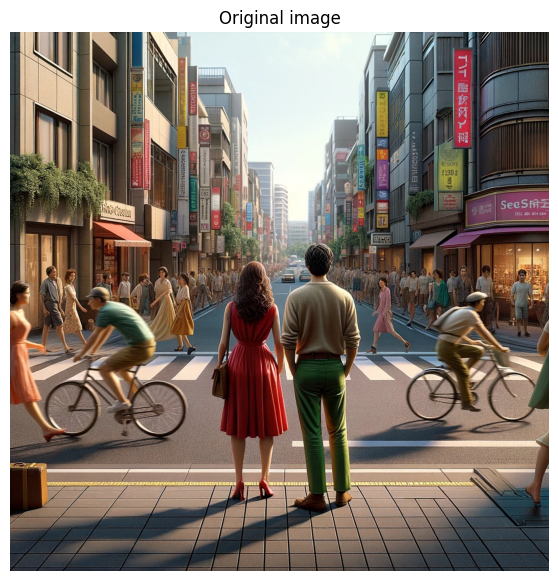

In [ ]:
# Import the input image
street = io.imread("street.jpg")

# Convert the image to floating-point values in the range [0, 1].
# This makes the image compatible with the color conversion functions used later.
street = street.astype(float) / 255.0

# Visualize the loaded image
plt.figure(figsize=(7, 7))
plt.imshow(street)  # Display the original RGB image.
plt.title("Original image")
plt.axis("off")
plt.show() # Show the figure.

The original image is displayed above. It contains some clearly red elements, such as the red dress and some red signs. These are the areas that should remain in full color in the final result.

## Convert RGB image to HSV

To identify red pixels more easily, the image is **converted from RGB to HSV color space**. In RGB, color and brightness are mixed across the red, green and blue channels. In HSV, instead, the image is represented using Hue, Saturation and Value.

Hue describes the type of color, Saturation describes how intense or pure the color is, and Value describes the brightness of the pixel.

In [ ]:
# Convert the image from RGB to HSV color space
street_hsv = rgb2hsv(street)

# Extract the three HSV channels
hue = street_hsv[:, :, 0]  # This channel is used to identify the color of each pixel.
saturation = street_hsv[:, :, 1]  # This channel is used to select only strong and vivid colors.
value = street_hsv[:, :, 2]  # This channel represents the brightness of the image.

Before creating the mask, it is useful to visualize the HSV channels separately. This helps to understand which information is contained in each channel and why HSV is appropriate for this task.

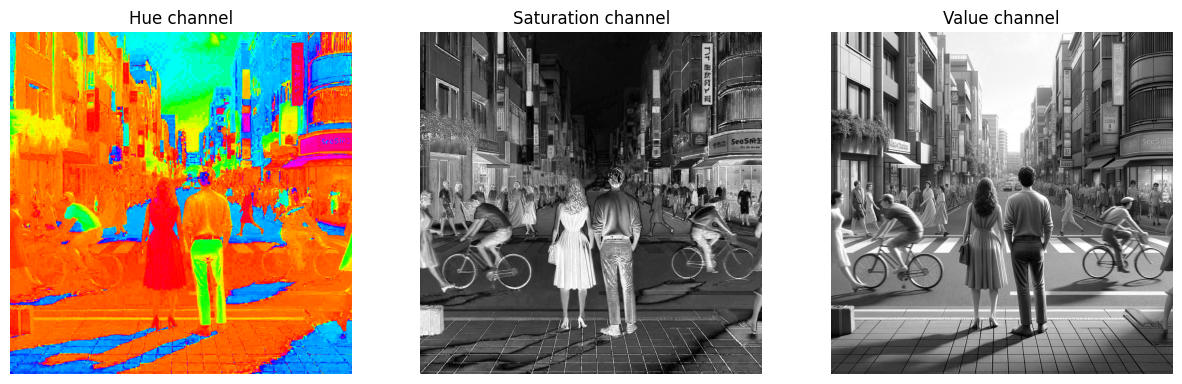

In [ ]:
# Visualize the Hue, Saturation and Value channels.
# This helps to understand how the HSV color space separates color,
# color intensity and brightness.

plt.figure(figsize=(15, 5))

# Display the Hue channel.
plt.subplot(1, 3, 1)
plt.imshow(hue, cmap="hsv")
plt.title("Hue channel")
plt.axis("off")

# Display the Saturation channel
plt.subplot(1, 3, 2)
plt.imshow(saturation, cmap="gray")
plt.title("Saturation channel")
plt.axis("off")

# Display the Value channel.
plt.subplot(1, 3, 3)
plt.imshow(value, cmap="gray")
plt.title("Value channel")
plt.axis("off")

# Show the three HSV channel visualizations.
plt.show()

The Hue channel contains the color information, the Saturation channel shows how intense the colors are, and the Value channel represents brightness. Since the assignment asks to include only very saturated red pixels, both **Hue and Saturation are necessary for defining the mask.**

## The red mask
The red mask is the key part of the assignment. A mask is a **boolean array** with the same height and width as the image. It contains `True` for pixels selected as red and `False` for all the other pixels.

A special aspect of Hue is that it is circular. In `skimage`, Hue values are in the range `[0, 1]`. Red appears both close to `0` and close to `1`, because after `1` the Hue value wraps around again to `0`. For this reason, two intervals are used: one near `0` and one near `1`.

A **Saturation threshold** is also applied to keep only very saturated pixels. This avoids selecting pale red, orange, brown, skin tones or grayish areas.


In [ ]:
# Define a mask for red pixels.

# Define the Hue condition for red pixels.
# Hue is circular, so red appears both close to 0 and close to 1.
# For this reason, two intervals are used:
# - hue < 0.04 selects red values near 0
# - hue > 0.96 selects red values near 1
red_hue_mask = (hue < 0.04) | (hue > 0.96)

# Define the Saturation condition.
# Only pixels with high saturation are selected.
# This avoids including pale red, orange, brown, skin tones or grayish areas.
saturated_mask = saturation > 0.60

# Combine the two conditions to obtain the final red mask.
# A pixel is selected only if:
# - its Hue corresponds to red
# - its Saturation is high enough
red_mask = red_hue_mask & saturated_mask

The final mask selects only pixels that satisfy two conditions at the same time: their Hue must correspond to red, considering the circular nature of Hue, and their Saturation must be high enough. This makes the selection more precise and consistent with the assignment requirements.

The mask can now be visualized as a binary image.
* White pixels correspond to the selected red regions;
* Black pixels correspond to the parts of the image that will later become grayscale.

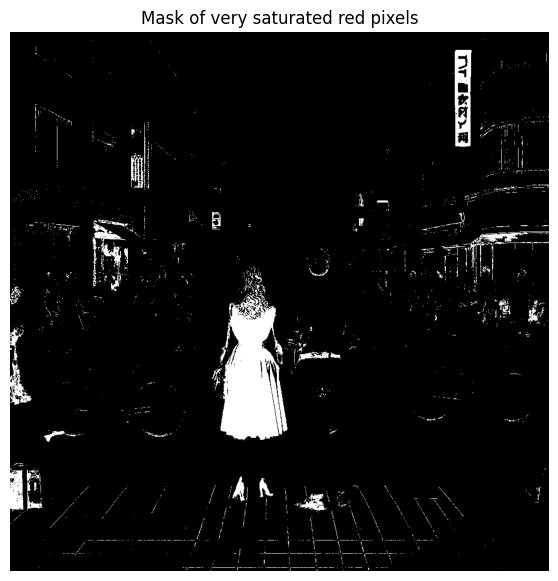

In [ ]:
# Visualize the mask.
# White pixels correspond to the areas selected as red.
# Black pixels correspond to the areas that will become grayscale.
plt.figure(figsize=(7, 7))
plt.imshow(red_mask, cmap="gray")
plt.title("Mask of very saturated red pixels")
plt.axis("off")  # Hide the axis
plt.show()  # Show the mask.

The white areas represent the pixels classified as very saturated red. This visualization is useful to check whether the mask is selecting the correct regions before creating the final processed image.

To inspect the mask more clearly, it can be overlaid on the original image. In the following visualization, pixels outside the mask are darkened, while the selected red pixels keep their original color.

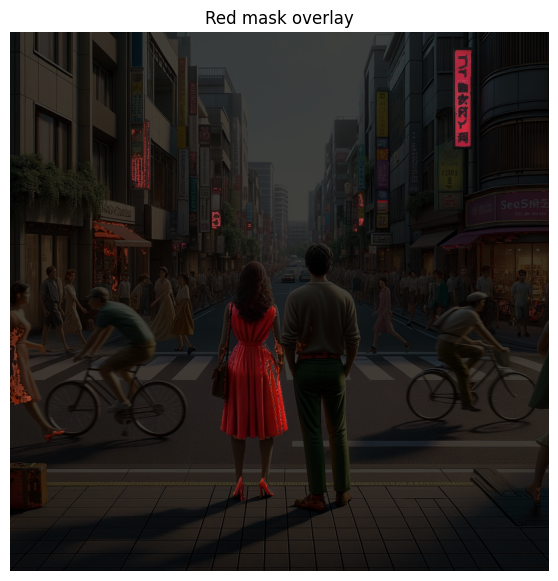

In [ ]:
# Create a copy of the original image
mask_overlay = street.copy()

# Darken all pixels outside the red mask
mask_overlay[~red_mask] = mask_overlay[~red_mask] * 0.25 # Multiplying by 0.25 makes those pixels darker.

# Display the overlay
plt.figure(figsize=(7, 7))
plt.imshow(mask_overlay) # Display the image with non-red areas darkened.
plt.title("Red mask overlay")
plt.axis("off")
plt.show() # Show the overlay image.

The overlay helps verify that the mask mainly selects the strong red parts of the image. This is an important intermediate check, because the quality of the final result depends directly on the quality of the mask.

A small quantitative check can also be useful. By counting the number of selected pixels, we can measure **how much of the image has been classified as very saturated red**.

In [ ]:
# Count how many pixels are selected by the red mask.
# Since True is counted as 1 and False as 0, np.sum gives the number of red pixels.
red_pixels = np.sum(red_mask)

# Count the total number of pixels in the image.
# red_mask.size gives height × width.
total_pixels = red_mask.size

# Compute the percentage of selected red pixels.
red_percentage = (red_pixels / total_pixels) * 100

#Print the results
print("Number of red pixels:", red_pixels)
print("Total number of pixels:", total_pixels)
print("Percentage of red pixels: {:.2f}%".format(red_percentage))

Number of red pixels: 62942
Total number of pixels: 1048576
Percentage of red pixels: 6.00%


The percentage of selected red pixels is expected to be relatively small, because only the very saturated red parts of the image should be preserved in color. This confirms that **the mask is selective rather than broad.**

## Convert the image to grayscale
After defining the red mask, a grayscale version of the original image is created. This grayscale image will be used as the base of the final output.

The grayscale image is then converted back to RGB format. This is necessary because the final image must have three channels: grayscale values outside the mask and original RGB values inside the mask.

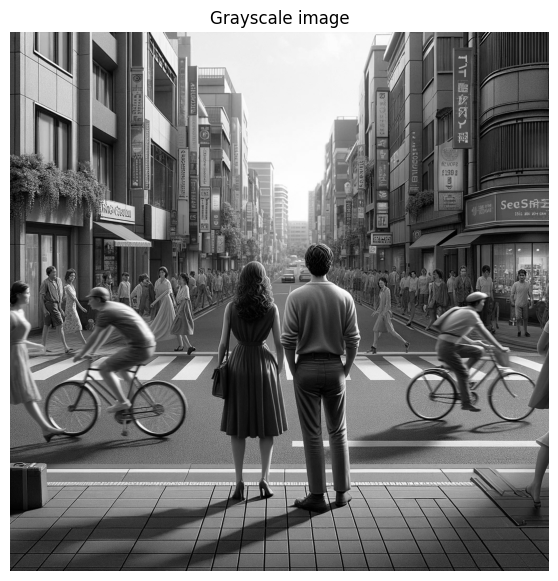

In [ ]:
# Convert the original RGB image to grayscale.
# The result is a 2D image containing only intensity values.
street_gray = rgb2gray(street)

# Convert the grayscale image back to RGB format.
# This gives a 3-channel grayscale image, which can be combined with the original RGB image.
street_gray_rgb = gray2rgb(street_gray)

# Visualize the grayscale image
plt.figure(figsize=(7, 7))
plt.imshow(street_gray_rgb)
plt.title("Grayscale image")
plt.axis("off")
plt.show()

This image shows how the scene looks when all color information is removed. In the next step, only the pixels selected by the red mask will be restored from the original color image.

In [ ]:
# Start from the grayscale RGB image.
# At this point, the whole image is grayscale.
street_processed = street_gray_rgb.copy()

# Replace only the pixels selected by the red mask with the original RGB pixels.
# In this way, red regions remain in full color,
# while all the other pixels stay grayscale.
street_processed[red_mask] = street[red_mask]

The final image is created by starting from the grayscale version. Then, for all pixels where the red mask is `True`, the original RGB values are copied back from the original image.

This means that red pixels remain in full color, while every pixel outside the mask remains grayscale.

## Result Visualization
The final result is visualized next to the original image. This comparison makes it possible to evaluate the effect of the selective color rendering.

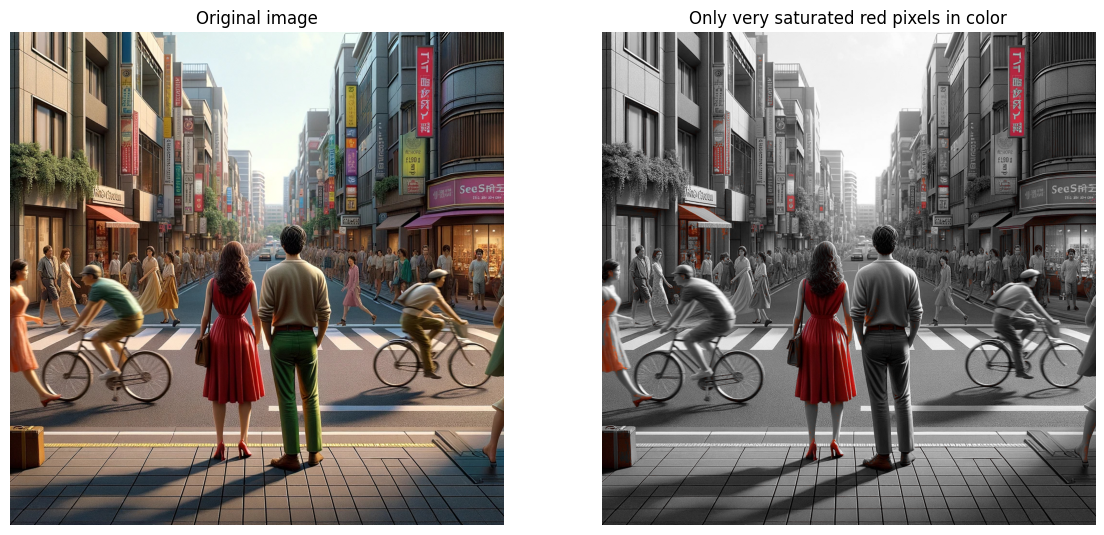

In [ ]:
# Visualize the original image and the final processed image side by side.
# Display the original and processed images side by side
plt.figure(figsize=(14, 7))

# Display the original image on the left.
plt.subplot(1, 2, 1)
plt.imshow(street)
plt.title("Original image")
plt.axis("off")

# Display the processed image on the right.
plt.subplot(1, 2, 2)
plt.imshow(street_processed)
plt.title("Only very saturated red pixels in color")
plt.axis("off")

# Show the final comparison.
plt.show()

The processed image has now been created. It combines the grayscale version of the image with the original red pixels selected by the mask.

## Final conclusion

In this assignment, the image `street.jpg` was processed to keep only the red regions in full color and convert the rest of the image to grayscale.

The image was **converted from RGB to HSV color space** because HSV makes it easier to detect specific colors. The **red mask** was created using two Hue intervals, since red appears both near `0` and near `1` due to the circular nature of Hue.

A **high Saturation threshold** was used to select only strong and clearly visible red pixels. Finally, the original RGB values were restored only where the mask was true, while all other pixels remained grayscale.

The final result shows that HSV-based masking is an effective method **for selective color rendering.**